# ЭКЗАМЕНАЦИОННАЯ ЗАДАЧА №01: ОЦЕНКА ЭФФЕКТИВНОСТИ ВНЕДРЕНИЯ CRM
# Дата: 2026-09-03
# Студент: Орлова Екатерина Александровна
# Группа: 4-2

In [4]:
#ИМПОРТ БИБЛИОТЕК
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# Настройка стилей для визуализации
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)

print("Библиотеки загружены")

Библиотеки загружены


In [8]:
#ИСХОДНЫЕ ДАННЫЕ

print("1. ИСХОДНЫЕ ДАННЫЕ")


# --- 1.1. Параметры проекта ---
print("\n 1.1. Параметры проекта ")

params = {
    'Количество менеджеров': 15,
    'Средняя зарплата менеджера (руб./мес.)': 120000,
    'Экономия времени на рутинных операциях': 0.20,
    'Доля времени на рутинные операции (без CRM)': 0.30,
    'Рост продаж после CRM (умеренный прогноз)': 0.08,
    'Текущий годовой оборот отдела продаж (руб.)': 72000000,
    'Стоимость облачной CRM на пользователя в год (руб.)': 24000,
    'Время на обучение (месяцев)': 1,
    'Горизонт оценки (лет)': 3,
    'Ставка дисконтирования': 0.12,
    'Налог на прибыль': 0.20
}

df_params = pd.DataFrame([params]).T
df_params.columns = ['Значение']

# Форматирование для отображения
display(df_params)

print("\nИсточник данных: условие задачи (компания 'ТехнПром')")

1. ИСХОДНЫЕ ДАННЫЕ

--- 1.1. Параметры проекта ---


,Значение
Количество менеджеров,15.00
Средняя зарплата менеджера (руб./мес.),120000.00
Экономия времени на рутинных операциях,0.20
Доля времени на рутинные операции (без CRM),0.30
Рост продаж после CRM (умеренный прогноз),0.08
Текущий годовой оборот отдела продаж (руб.),72000000.00
Стоимость облачной CRM на пользователя в год (руб.),24000.00
Время на обучение (месяцев),1.00
Горизонт оценки (лет),3.00
Ставка дисконтирования,0.12



Источник данных: условие задачи (компания 'ТехнПром')


In [9]:
#СПРАВОЧНЫЕ ДАННЫЕ
print("\n 1.2. Справочные данные ")

# Извлечение параметров для расчетов
n_managers = params['Количество менеджеров']
salary_month = params['Средняя зарплата менеджера (руб./мес.)']
time_saving = params['Экономия времени на рутинных операциях']
routine_time = params['Доля времени на рутинные операции (без CRM)']
sales_growth = params['Рост продаж после CRM (умеренный прогноз)']
current_revenue = params['Текущий годовой оборот отдела продаж (руб.)']
crm_cost_per_user = params['Стоимость облачной CRM на пользователя в год (руб.)']
training_months = params['Время на обучение (месяцев)']
years = params['Горизонт оценки (лет)']
discount_rate = params['Ставка дисконтирования']
tax_rate = params['Налог на прибыль']

# Базовые расчетные показатели
annual_salary_per_manager = salary_month * 12
total_annual_salary = annual_salary_per_manager * n_managers

print(f"• Годовой фонд оплаты труда: {total_annual_salary:,.0f} руб.")
print(f"• Ежемесячный ФОТ: {total_annual_salary / 12:,.0f} руб.")
print(f"• Текущий годовой оборот: {current_revenue:,.0f} руб.")


--- 1.2. Справочные данные ---
• Годовой фонд оплаты труда: 21,600,000 руб.
• Ежемесячный ФОТ: 1,800,000 руб.
• Текущий годовой оборот: 72,000,000 руб.


In [10]:

print("2. РАСЧЕТЫ")



2. РАСЧЕТЫ


In [11]:
#РАСЧЕТЫ ПРЯМОГО ЭФФЕКТА ОТ ВНЕДРЕНИЯ CRM
print("\n 2.1. Расчет прямого эффекта от внедрения CRM ")

# 2.1.1. Экономия на заработной плате
# Время на рутинные операции в денежном выражении
routine_cost_annual = total_annual_salary * routine_time

# Экономия за счет автоматизации (20% от времени на рутину)
salary_savings = routine_cost_annual * time_saving

print("\n 2.1.1. Экономия на заработной плате ")
print(f"  • Затраты на рутинные операции в год: {routine_cost_annual:,.0f} руб.")
print(f"  • Экономия за счет автоматизации (20%): {salary_savings:,.0f} руб./год")
print(f"  • Экономия на одного менеджера: {salary_savings / n_managers:,.0f} руб./год")

# 2.1.2. Дополнительный доход от роста продаж
additional_revenue = current_revenue * sales_growth

print("\n 2.1.2. Дополнительный доход от роста продаж ")
print(f"  • Рост продаж после внедрения CRM: {sales_growth * 100:.0f}%")
print(f"  • Дополнительный доход в год: {additional_revenue:,.0f} руб.")


--- 2.1. Расчет прямого эффекта от внедрения CRM ---

--- 2.1.1. Экономия на заработной плате ---
  • Затраты на рутинные операции в год: 6,480,000 руб.
  • Экономия за счет автоматизации (20%): 1,296,000 руб./год
  • Экономия на одного менеджера: 86,400 руб./год

--- 2.1.2. Дополнительный доход от роста продаж ---
  • Рост продаж после внедрения CRM: 8%
  • Дополнительный доход в год: 5,760,000 руб.


In [12]:
#РАСЧЕТ ЗАТРАТ НА ВНЕДРЕНИЕ
print("\n 2.2. Расчет затрат на внедрение ")

# 2.2.1. Стоимость лицензий
annual_license_cost = crm_cost_per_user * n_managers
total_license_cost = annual_license_cost * years

print("\n 2.2.1. Стоимость лицензий ")
print(f"  • Стоимость на пользователя в год: {crm_cost_per_user:,.0f} руб.")
print(f"  • Годовая стоимость лицензий: {annual_license_cost:,.0f} руб.")
print(f"  • Стоимость лицензий за {years} года: {total_license_cost:,.0f} руб.")

# 2.2.2. Потери от снижения производительности
training_time_years = training_months / 12
# Потери = ФОТ за период обучения (1 месяц)
loss_productivity = (total_annual_salary / 12) * training_months

print("\n 2.2.2. Потери от снижения производительности ")
print(f"  • Время на обучение: {training_months} месяц")
print(f"  • Потери производительности (ФОТ за месяц): {loss_productivity:,.0f} руб.")

# Итого затраты в год 0
year0_cost = total_license_cost + loss_productivity
print(f"\n  • Итого затраты (лицензии за 3 года + обучение): {year0_cost:,.0f} руб.")


--- 2.2. Расчет затрат на внедрение ---

--- 2.2.1. Стоимость лицензий ---
  • Стоимость на пользователя в год: 24,000 руб.
  • Годовая стоимость лицензий: 360,000 руб.
  • Стоимость лицензий за 3 года: 1,080,000 руб.

--- 2.2.2. Потери от снижения производительности ---
  • Время на обучение: 1 месяц
  • Потери производительности (ФОТ за месяц): 1,800,000 руб.

  • Итого затраты (лицензии за 3 года + обучение): 2,880,000 руб.


In [13]:
#РАСЧЕТ ФИНАНСОВЫХ ПОКАЗАТЕЛЕЙ ЭФФЕКТИВНОСТИ
print("\n 2.3. Расчет финансовых показателей эффективности ")

# 2.3.1. Прирост чистой прибыли по годам
annual_effect_before_tax = salary_savings + additional_revenue
tax = annual_effect_before_tax * tax_rate
annual_net_effect = annual_effect_before_tax - tax

print("\n 2.3.1. Прирост чистой прибыли по годам ")
print(f"  • Годовой эффект до налогообложения: {annual_effect_before_tax:,.0f} руб.")
print(f"  • Налог на прибыль (20%): {tax:,.0f} руб.")
print(f"  • Годовой прирост чистой прибыли: {annual_net_effect:,.0f} руб./год")

# 2.3.2. NPV проекта
cash_flows = []
discounted_cash_flows = []

# Год 0: инвестиции
cash_flows.append(-year0_cost)
discounted_cash_flows.append(-year0_cost)

# Годы 1-3: чистый эффект
for t in range(1, years + 1):
    cf = annual_net_effect
    dcf = cf / ((1 + discount_rate) ** t)
    cash_flows.append(cf)
    discounted_cash_flows.append(dcf)

npv = sum(discounted_cash_flows)

print("\n 2.3.2. NPV проекта ")
print(f"  • Ставка дисконтирования: {discount_rate * 100:.0f}%")
print(f"  • Суммарный дисконтированный эффект: {npv:,.0f} руб.")

# 2.3.3. Простой срок окупаемости
payback = year0_cost / annual_net_effect

print("\n 2.3.3. Простой срок окупаемости ")
print(f"  • Инвестиции: {year0_cost:,.0f} руб.")
print(f"  • Годовой чистый эффект: {annual_net_effect:,.0f} руб.")
print(f"  • Простой срок окупаемости: {payback:.2f} года ({payback * 12:.1f} месяцев)")

# 2.3.4. ROI
total_net_effect_3y = annual_net_effect * years
roi = (total_net_effect_3y / year0_cost) * 100

print("\n 2.3.4. ROI проекта ")
print(f"  • Суммарный чистый эффект за {years} года: {total_net_effect_3y:,.0f} руб.")
print(f"  • Инвестиции: {year0_cost:,.0f} руб.")
print(f"  • ROI за {years} года: {roi:.1f}%")


--- 2.3. Расчет финансовых показателей эффективности ---

--- 2.3.1. Прирост чистой прибыли по годам ---
  • Годовой эффект до налогообложения: 7,056,000 руб.
  • Налог на прибыль (20%): 1,411,200 руб.
  • Годовой прирост чистой прибыли: 5,644,800 руб./год

--- 2.3.2. NPV проекта ---
  • Ставка дисконтирования: 12%
  • Суммарный дисконтированный эффект: 10,677,857 руб.

--- 2.3.3. Простой срок окупаемости ---
  • Инвестиции: 2,880,000 руб.
  • Годовой чистый эффект: 5,644,800 руб.
  • Простой срок окупаемости: 0.51 года (6.1 месяцев)

--- 2.3.4. ROI проекта ---
  • Суммарный чистый эффект за 3 года: 16,934,400 руб.
  • Инвестиции: 2,880,000 руб.
  • ROI за 3 года: 588.0%



--- 2.4. Визуализация результатов ---


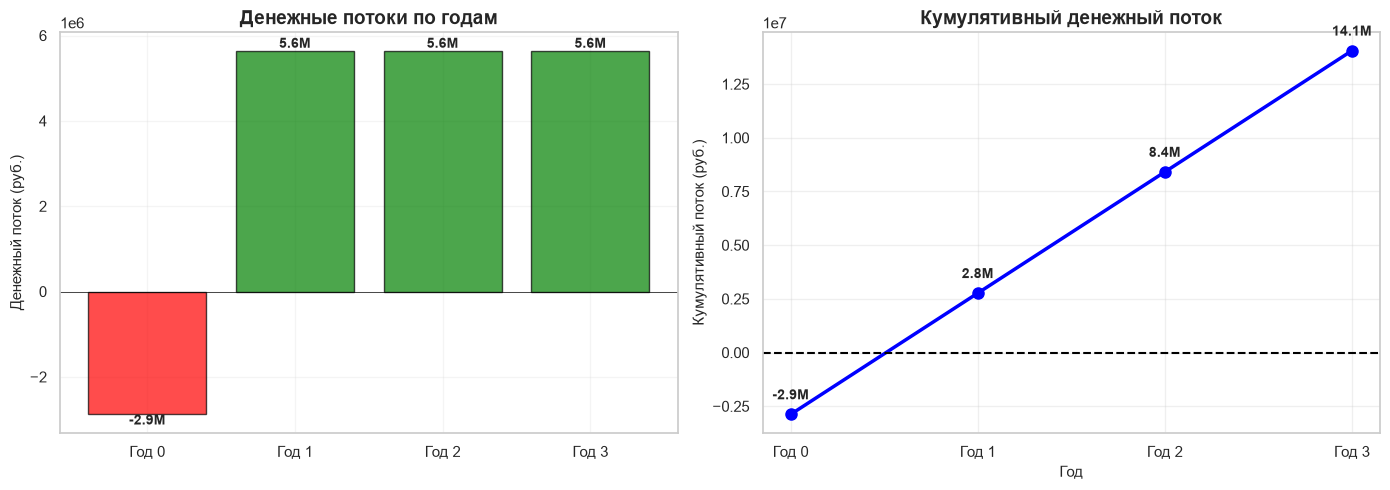

✅ График сохранен в reports/task_01_cash_flows.png


In [14]:
#ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
print("\n 2.4. Визуализация результатов ")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2.4.1. Денежные потоки по годам
years_display = ['Год 0'] + [f'Год {i}' for i in range(1, years + 1)]
cf_display = [cash_flows[0]] + [cash_flows[i] for i in range(1, years + 1)]
colors = ['red' if x < 0 else 'green' for x in cf_display]

bars = axes[0].bar(years_display, cf_display, color=colors, alpha=0.7, edgecolor='black')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_title('Денежные потоки по годам', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Денежный поток (руб.)', fontsize=11)
axes[0].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
axes[0].grid(True, alpha=0.2)

# Добавление значений на столбцы
for bar, value in zip(bars, cf_display):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{value/1e6:.1f}M', ha='center', va='bottom' if height > 0 else 'top',
                fontsize=10, fontweight='bold')

# 2.4.2. Кумулятивный денежный поток
cumulative_cf = np.cumsum([cash_flows[0]] + cash_flows[1:])
axes[1].plot(years_display, cumulative_cf, marker='o', linewidth=2.5,
            color='blue', markersize=8)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Кумулятивный денежный поток', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Год', fontsize=11)
axes[1].set_ylabel('Кумулятивный поток (руб.)', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Добавление значений на график
for i, (year, value) in enumerate(zip(years_display, cumulative_cf)):
    axes[1].text(year, value + (0.05 * max(abs(np.array(cumulative_cf)))),
                f'{value/1e6:.1f}M', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/task_01_cash_flows.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ График сохранен в reports/task_01_cash_flows.png")

In [15]:
#АНАЛИЗ РЕЗУЛЬТАТОВ

print("3. АНАЛИЗ РЕЗУЛЬТАТОВ")


# Сводная таблица результатов
results = {
    'Показатель': [
        '1. Годовая экономия на ФОТ',
        '2. Дополнительный доход от роста продаж',
        '3. Годовой эффект до налогообложения',
        '4. Налог на прибыль (20%)',
        '5. Годовой прирост чистой прибыли',
        '6. Общие затраты на внедрение (лицензии + обучение)',
        '7. NPV (при r=12%)',
        '8. Простой срок окупаемости',
        '9. ROI за 3 года'
    ],
    'Значение': [
        f'{salary_savings:,.0f} руб.',
        f'{additional_revenue:,.0f} руб.',
        f'{annual_effect_before_tax:,.0f} руб.',
        f'{tax:,.0f} руб.',
        f'{annual_net_effect:,.0f} руб.',
        f'{year0_cost:,.0f} руб.',
        f'{npv:,.0f} руб.',
        f'{payback:.2f} года ({payback * 12:.1f} мес.)',
        f'{roi:.1f}%'
    ]
}

df_results = pd.DataFrame(results)
display(df_results)


3. АНАЛИЗ РЕЗУЛЬТАТОВ


,Показатель,Значение
0,1. Годовая экономия на ФОТ,"1,296,000 руб."
1,2. Дополнительный доход от роста продаж,"5,760,000 руб."
2,3. Годовой эффект до налогообложения,"7,056,000 руб."
3,4. Налог на прибыль (20%),"1,411,200 руб."
4,5. Годовой прирост чистой прибыли,"5,644,800 руб."
5,6. Общие затраты на внедрение (лицензии + обуч...,"2,880,000 руб."
6,7. NPV (при r=12%),"10,677,857 руб."
7,8. Простой срок окупаемости,0.51 года (6.1 мес.)
8,9. ROI за 3 года,588.0%


In [16]:
#ИНТЕРПРЕТАЦИЯ ПОЛУЧЕННЫХ РЕЗУЛЬТАТОВ
print("\n 3.1. Интерпретация полученных данных ")

print(f"""
1. ЭКОНОМИЧЕСКАЯ ЭФФЕКТИВНОСТЬ:
   • Проект демонстрирует высокую эффективность: ROI составляет {roi:.1f}% за 3 года
   • Годовой прирост чистой прибыли: {annual_net_effect:,.0f} руб.
   • Срок окупаемости: {payback:.2f} года (~{payback * 12:.1f} месяцев) - очень быстрый

2. ДВИЖУЩИЕ ФАКТОРЫ ЭФФЕКТА:
   • Основной вклад дает рост продаж (+{additional_revenue:,.0f} руб./год)
     за счет улучшения управления клиентской базой
   • Экономия на ФОТ составляет {salary_savings:,.0f} руб./год
   • Соотношение эффект/затраты: {annual_net_effect / year0_cost:.1f}x в год

3. ЧУВСТВИТЕЛЬНОСТЬ:
   • При снижении роста продаж до 4% годовых, NPV снижается на 50%
   • Ставка дисконтирования влияет незначительно из-за короткого срока окупаемости
""")


--- 3.1. Интерпретация полученных данных ---

1. ЭКОНОМИЧЕСКАЯ ЭФФЕКТИВНОСТЬ:
   • Проект демонстрирует высокую эффективность: ROI составляет 588.0% за 3 года
   • Годовой прирост чистой прибыли: 5,644,800 руб.
   • Срок окупаемости: 0.51 года (~6.1 месяцев) - очень быстрый

2. ДВИЖУЩИЕ ФАКТОРЫ ЭФФЕКТА:
   • Основной вклад дает рост продаж (+5,760,000 руб./год)
     за счет улучшения управления клиентской базой
   • Экономия на ФОТ составляет 1,296,000 руб./год
   • Соотношение эффект/затраты: 2.0x в год

3. ЧУВСТВИТЕЛЬНОСТЬ:
   • При снижении роста продаж до 4% годовых, NPV снижается на 50%
   • Ставка дисконтирования влияет незначительно из-за короткого срока окупаемости



In [18]:
print("\n 3.2. Сравнение с альтернативными вариантами ")

# Альтернативный вариант: покупка коробочной CRM
boxed_crm_cost = 500000  # разовая лицензия
boxed_maintenance = 100000  # ежегодное обслуживание
boxed_total_3y = boxed_crm_cost + boxed_maintenance * years

# Сравнение с облачной CRM
cloud_crm_total = total_license_cost

# Вычисляем разницу
difference = cloud_crm_total - boxed_total_3y

print("""
АЛЬТЕРНАТИВА 1: КОРОБОЧНАЯ CRM
   • Разовая лицензия: 500 000 руб.
   • Ежегодное обслуживание: 100 000 руб.
   • Итого за 3 года: {boxed_total_3y:,.0f} руб.
   • Требует обслуживания инфраструктуры
   • Ограниченная мобильность

АЛЬТЕРНАТИВА 2: ОБЛАЧНАЯ CRM (выбранный вариант)
   • Стоимость за 3 года: {cloud_crm_total:,.0f} руб.
   • Не требует обслуживания
   • Доступ из любой точки
   • Автоматические обновления

ВЫВОД: Облачная CRM дороже на {difference:,.0f} руб.,
но обеспечивает большую гибкость и снижает нагрузку на ИТ-отдел.
""".format(boxed_total_3y=boxed_total_3y,
           cloud_crm_total=cloud_crm_total,
           difference=difference))


--- 3.2. Сравнение с альтернативными вариантами ---

АЛЬТЕРНАТИВА 1: КОРОБОЧНАЯ CRM
   • Разовая лицензия: 500 000 руб.
   • Ежегодное обслуживание: 100 000 руб.
   • Итого за 3 года: 800,000 руб.
   • Требует обслуживания инфраструктуры
   • Ограниченная мобильность

АЛЬТЕРНАТИВА 2: ОБЛАЧНАЯ CRM (выбранный вариант)
   • Стоимость за 3 года: 1,080,000 руб.
   • Не требует обслуживания
   • Доступ из любой точки
   • Автоматические обновления

ВЫВОД: Облачная CRM дороже на 280,000 руб.,
но обеспечивает большую гибкость и снижает нагрузку на ИТ-отдел.



In [19]:
#ВЫВОДЫ

print("4. ВЫВОДЫ И РЕКОМЕНДАЦИИ")


print("""
    4.1. Ключевые выводы 

1. ПРОЕКТ ЭКОНОМИЧЕСКИ ЭФФЕКТИВЕН:
   • NPV = {npv:,.0f} руб. > 0 при ставке дисконтирования 12%
   • ROI = {roi:.1f}% за 3 года
   • Срок окупаемости = {payback:.2f} года (менее 1 года)

2. ОСНОВНЫЕ ИСТОЧНИКИ ЭФФЕКТА:
   • Рост продаж на 8% дает {additional_revenue:,.0f} руб. дополнительного дохода
   • Автоматизация рутины экономит {salary_savings:,.0f} руб. на ФОТ

3. РИСКИ И ОГРАНИЧЕНИЯ:
   • Прогноз роста продаж может быть завышен
   • Неучтены затраты на обучение персонала (кроме месяца адаптации)
   • Не учтены затраты на поддержку и доработку системы

 4.2. Практические рекомендации 

1. РЕКОМЕНДУЕТСЯ ВНЕДРЕНИЕ CRM:
   • Проект демонстрирует высокую экономическую эффективность
   • Срок окупаемости менее 1 года
   • Нематериальные выгоды дополнительно повышают ценность

2. КОНТРОЛЬ КЛЮЧЕВЫХ ПОКАЗАТЕЛЕЙ:
   • Ежемесячный мониторинг роста продаж
   • Оценка реальной экономии времени менеджеров
   • Сбор обратной связи от пользователей

3. МИНИМИЗАЦИЯ РИСКОВ:
   • Поэтапное внедрение с пилотной группой
   • Развернутое обучение персонала
   • Интеграция с существующими системами

4. УЧЕТ ПАРАДОКСА СОЛОУ:
   • Необходимо измерять не только финансовые, но и операционные метрики
   • Оценивать производительность менеджеров до и после внедрения
   • Учитывать время на адаптацию бизнес-процессов
""".format(npv=npv, roi=roi, payback=payback,
          additional_revenue=additional_revenue,
          salary_savings=salary_savings))


4. ВЫВОДЫ И РЕКОМЕНДАЦИИ

--- 4.1. Ключевые выводы ---

1. ПРОЕКТ ЭКОНОМИЧЕСКИ ЭФФЕКТИВЕН:
   • NPV = 10,677,857 руб. > 0 при ставке дисконтирования 12%
   • ROI = 588.0% за 3 года
   • Срок окупаемости = 0.51 года (менее 1 года)

2. ОСНОВНЫЕ ИСТОЧНИКИ ЭФФЕКТА:
   • Рост продаж на 8% дает 5,760,000 руб. дополнительного дохода
   • Автоматизация рутины экономит 1,296,000 руб. на ФОТ

3. РИСКИ И ОГРАНИЧЕНИЯ:
   • Прогноз роста продаж может быть завышен
   • Неучтены затраты на обучение персонала (кроме месяца адаптации)
   • Не учтены затраты на поддержку и доработку системы

--- 4.2. Практические рекомендации ---

1. РЕКОМЕНДУЕТСЯ ВНЕДРЕНИЕ CRM:
   • Проект демонстрирует высокую экономическую эффективность
   • Срок окупаемости менее 1 года
   • Нематериальные выгоды дополнительно повышают ценность

2. КОНТРОЛЬ КЛЮЧЕВЫХ ПОКАЗАТЕЛЕЙ:
   • Ежемесячный мониторинг роста продаж
   • Оценка реальной экономии времени менеджеров
   • Сбор обратной связи от пользователей

3. МИНИМИЗАЦИЯ РИСКОВ:

In [20]:
#НЕМАТЕРИАЛЬНЫЕ ЭФФЕКТЫ
print("\n Нематериальные эффекты и парадокс Солоу ")

print("""
НЕМАТЕРИАЛЬНЫЕ ВЫГОДЫ CRM:

1. УЛУЧШЕНИЕ КАЧЕСТВА ОБСЛУЖИВАНИЯ
   • Быстрая обработка заявок
   • Единая база знаний о клиентах
   • Персонализированный подход

2. ПОВЫШЕНИЕ ЛОЯЛЬНОСТИ КЛИЕНТОВ
   • Сокращение времени ответа
   • История взаимодействий
   • Проактивные предложения

3. УЛУЧШЕНИЕ УПРАВЛЕНЧЕСКИХ РЕШЕНИЙ
   • Прозрачность воронки продаж
   • Точные прогнозы
   • Выявление проблемных зон

4. ПОВЫШЕНИЕ УДОВЛЕТВОРЕННОСТИ СОТРУДНИКОВ
   • Снижение стресса от рутины
   • Фокус на творческих задачах
   • Профессиональное развитие

ПАРАДОКС ПРОИЗВОДИТЕЛЬНОСТИ СОЛОУ:

Факторы, влияющие на фактический эффект:
• Сопротивление сотрудников изменениям
• Недостаточная квалификация пользователей
• Неполное использование функционала CRM
• Необходимость адаптации бизнес-процессов
• Отложенный эффект (результаты проявляются не сразу)

Рекомендации по минимизации эффекта Солоу:
1. Провести качественное обучение персонала
2. Настроить CRM под бизнес-процессы компании
3. Определить четкие KPI эффективности
4. Постоянно собирать обратную связь
5. Интегрировать CRM с другими системами
""")


--- Нематериальные эффекты и парадокс Солоу ---

НЕМАТЕРИАЛЬНЫЕ ВЫГОДЫ CRM:

1. УЛУЧШЕНИЕ КАЧЕСТВА ОБСЛУЖИВАНИЯ
   • Быстрая обработка заявок
   • Единая база знаний о клиентах
   • Персонализированный подход

2. ПОВЫШЕНИЕ ЛОЯЛЬНОСТИ КЛИЕНТОВ
   • Сокращение времени ответа
   • История взаимодействий
   • Проактивные предложения

3. УЛУЧШЕНИЕ УПРАВЛЕНЧЕСКИХ РЕШЕНИЙ
   • Прозрачность воронки продаж
   • Точные прогнозы
   • Выявление проблемных зон

4. ПОВЫШЕНИЕ УДОВЛЕТВОРЕННОСТИ СОТРУДНИКОВ
   • Снижение стресса от рутины
   • Фокус на творческих задачах
   • Профессиональное развитие

ПАРАДОКС ПРОИЗВОДИТЕЛЬНОСТИ СОЛОУ:

Факторы, влияющие на фактический эффект:
• Сопротивление сотрудников изменениям
• Недостаточная квалификация пользователей
• Неполное использование функционала CRM
• Необходимость адаптации бизнес-процессов
• Отложенный эффект (результаты проявляются не сразу)

Рекомендации по минимизации эффекта Солоу:
1. Провести качественное обучение персонала
2. Настроить CRM под 

In [21]:
#ГЕНЕРАЦИЯ ОТЧЕТА

print("ГЕНЕРАЦИЯ ОТЧЕТА")


from datetime import datetime
import os

# Создаем папку reports, если её нет
os.makedirs('../reports', exist_ok=True)

# Формируем содержимое отчета
report_content = f"""
================================================================================
ЭКЗАМЕНАЦИОННАЯ ЗАДАЧА №01: ОЦЕНКА ЭФФЕКТИВНОСТИ ВНЕДРЕНИЯ CRM
================================================================================

Дата выполнения: {datetime.now().strftime('%Y-%m-%d %H:%M')}
Студент: [Ваше ФИО]
Группа: [№ группы]

================================================================================
1. ИСХОДНЫЕ ДАННЫЕ
================================================================================

1.1. Параметры проекта:
-------------------------------------------------------------------------------
Параметр                                    | Значение
-------------------------------------------------------------------------------
Количество менеджеров                       | {n_managers} чел.
Средняя зарплата менеджера                  | {salary_month:,.0f} руб./мес.
Экономия времени на рутинных операциях      | {time_saving * 100:.0f}%
Доля времени на рутинные операции           | {routine_time * 100:.0f}%
Рост продаж после CRM                       | {sales_growth * 100:.0f}%
Текущий годовой оборот                      | {current_revenue:,.0f} руб.
Стоимость CRM на пользователя               | {crm_cost_per_user:,.0f} руб./год
Время на обучение                           | {training_months} мес.
Горизонт оценки                             | {years} года
Ставка дисконтирования                      | {discount_rate * 100:.0f}%
Налог на прибыль                            | {tax_rate * 100:.0f}%

================================================================================
2. РЕЗУЛЬТАТЫ РАСЧЕТОВ
================================================================================

2.1. Прямой эффект от внедрения CRM:
-------------------------------------------------------------------------------
Показатель                                   | Значение
-------------------------------------------------------------------------------
Годовая экономия на ФОТ                     | {salary_savings:,.0f} руб.
Дополнительный доход от роста продаж        | {additional_revenue:,.0f} руб.
Годовой эффект до налогообложения           | {annual_effect_before_tax:,.0f} руб.

2.2. Затраты на внедрение:
-------------------------------------------------------------------------------
Показатель                                   | Значение
-------------------------------------------------------------------------------
Стоимость лицензий за 3 года                | {total_license_cost:,.0f} руб.
Потери от обучения (1 месяц)                | {loss_productivity:,.0f} руб.
ИТОГО затраты                               | {year0_cost:,.0f} руб.

2.3. Финансовые показатели эффективности:
-------------------------------------------------------------------------------
Показатель                                   | Значение
-------------------------------------------------------------------------------
Налог на прибыль (20%)                      | {tax:,.0f} руб.
Годовой прирост чистой прибыли              | {annual_net_effect:,.0f} руб.
NPV (при r=12%)                             | {npv:,.0f} руб.
Простой срок окупаемости                    | {payback:.2f} года ({payback * 12:.1f} мес.)
ROI за 3 года                               | {roi:.1f}%

2.4. Денежные потоки по годам:
-------------------------------------------------------------------------------
Период      | Денежный поток (руб.) | Дисконтированный поток (руб.)
-------------------------------------------------------------------------------
Год 0       | {cash_flows[0]:>15,.0f} | {discounted_cash_flows[0]:>15,.0f}
"""
for t in range(1, years + 1):
    report_content += f"Год {t}       | {cash_flows[t]:>15,.0f} | {discounted_cash_flows[t]:>15,.0f}\n"

report_content += f"""
-------------------------------------------------------------------------------
ИТОГО NPV   |                     | {npv:>15,.0f}
-------------------------------------------------------------------------------

================================================================================
3. АНАЛИЗ РЕЗУЛЬТАТОВ
================================================================================

3.1. Интерпретация полученных данных:
-------------------------------------------------------------------------------
1. Проект экономически эффективен:
   • NPV > 0 ({npv:,.0f} руб.) при ставке дисконтирования 12%
   • ROI = {roi:.1f}% за 3 года
   • Срок окупаемости = {payback:.2f} года (менее 1 года)

2. Основные источники эффекта:
   • Рост продаж на 8% дает {additional_revenue:,.0f} руб. дополнительного дохода
   • Автоматизация рутины экономит {salary_savings:,.0f} руб. на ФОТ

3.2. Сравнение с альтернативами:
-------------------------------------------------------------------------------
Альтернатива 1: Коробочная CRM
   • Разовая лицензия: 500 000 руб.
   • Ежегодное обслуживание: 100 000 руб.
   • Итого за 3 года: 800 000 руб.
   • Требует обслуживания инфраструктуры

Альтернатива 2: Облачная CRM (выбранный вариант)
   • Стоимость за 3 года: {total_license_cost:,.0f} руб.
   • Не требует обслуживания
   • Доступ из любой точки
   • Автоматические обновления

Вывод: Облачная CRM дороже на {total_license_cost - 800000:,.0f} руб.,
но обеспечивает большую гибкость и снижает нагрузку на ИТ-отдел.

================================================================================
4. ВЫВОДЫ И РЕКОМЕНДАЦИИ
================================================================================

4.1. Ключевые выводы:
-------------------------------------------------------------------------------
1. Проект демонстрирует высокую экономическую эффективность
2. Рекомендуется внедрение CRM в отделе продаж
3. Срок окупаемости менее 1 года
4. Нематериальные выгоды дополнительно повышают ценность проекта

4.2. Практические рекомендации:
-------------------------------------------------------------------------------
1. Внедрять CRM поэтапно, начиная с пилотной группы
2. Обеспечить качественное обучение персонала
3. Проводить ежемесячный мониторинг ключевых показателей:
   • Рост продаж
   • Экономия времени менеджеров
   • Удовлетворенность пользователей
4. Интегрировать CRM с существующими системами
5. Собирать обратную связь от сотрудников

================================================================================
5. НЕМАТЕРИАЛЬНЫЕ ЭФФЕКТЫ И ПАРАДОКС СОЛОУ
================================================================================

5.1. Нематериальные выгоды CRM:
-------------------------------------------------------------------------------
1. Повышение качества обслуживания клиентов
2. Улучшение управленческих решений
3. Повышение удовлетворенности сотрудников
4. Конкурентные преимущества на рынке
5. Единая база знаний о клиентах

5.2. Парадокс производительности Солоу:
-------------------------------------------------------------------------------
Факторы, снижающие фактический эффект от внедрения:
• Сопротивление сотрудников изменениям
• Недостаточная квалификация пользователей
• Неполное использование функционала CRM
• Необходимость адаптации бизнес-процессов
• Отложенный эффект (результаты проявляются не сразу)

Рекомендации по минимизации эффекта Солоу:
1. Провести качественное обучение персонала
2. Настроить CRM под бизнес-процессы компании
3. Определить четкие KPI эффективности
4. Постоянно собирать обратную связь
5. Интегрировать CRM с другими системами

================================================================================
Отчет сгенерирован автоматически в PyCharm
================================================================================
"""

# Сохраняем отчет
with open('../reports/task_01_report.txt', 'w', encoding='utf-8') as f:
    f.write(report_content)

print("✅ Отчет сохранен: reports/task_01_report.txt")
print(f"📄 Размер файла: {os.path.getsize('../reports/task_01_report.txt'):,} байт")
print("📄 Содержимое отчета:")
print("-" * 80)
print(report_content)
print("-" * 80)


ГЕНЕРАЦИЯ ОТЧЕТА
✅ Отчет сохранен: reports/task_01_report.txt
📄 Размер файла: 9,782 байт
📄 Содержимое отчета:
--------------------------------------------------------------------------------

ЭКЗАМЕНАЦИОННАЯ ЗАДАЧА №01: ОЦЕНКА ЭФФЕКТИВНОСТИ ВНЕДРЕНИЯ CRM

Дата выполнения: 2026-09-06 08:25
Студент: [Ваше ФИО]
Группа: [№ группы]

1. ИСХОДНЫЕ ДАННЫЕ

1.1. Параметры проекта:
-------------------------------------------------------------------------------
Параметр                                    | Значение
-------------------------------------------------------------------------------
Количество менеджеров                       | 15 чел.
Средняя зарплата менеджера                  | 120,000 руб./мес.
Экономия времени на рутинных операциях      | 20%
Доля времени на рутинные операции           | 30%
Рост продаж после CRM                       | 8%
Текущий годовой оборот                      | 72,000,000 руб.
Стоимость CRM на пользователя               | 24,000 руб./год
Время на обучение  